In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

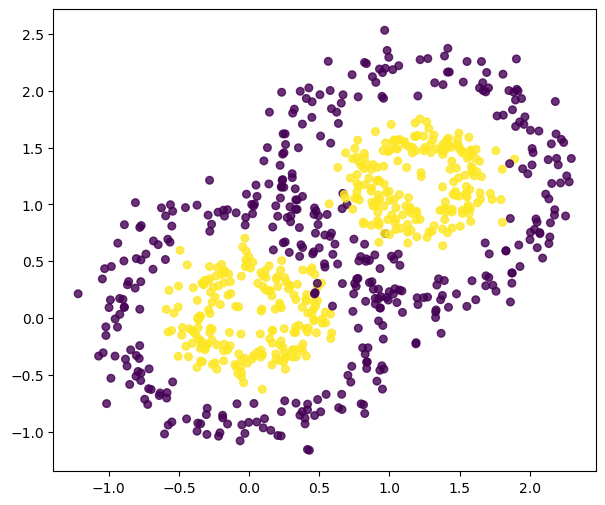

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# 1. Generate first set (centered at 0,0)
X1, y1 = make_circles(n_samples=400, factor=0.4, noise=0.12, random_state=42)

# 2. Generate second set and shift it slightly
X2, y2 = make_circles(n_samples=400, factor=0.4, noise=0.12, random_state=7)
# Use a smaller offset to make them overlap
X2 = X2 + [1.2, 1.2] 

# 3. Combine
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# 4. Plot
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=30, alpha=0.8)
plt.show()

In [12]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

# Without Batch Normalisation

In [13]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4266 - loss: 0.7113 - val_accuracy: 0.3688 - val_loss: 0.7014
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4313 - loss: 0.7073 - val_accuracy: 0.4187 - val_loss: 0.6967
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4469 - loss: 0.7041 - val_accuracy: 0.4500 - val_loss: 0.6944
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4531 - loss: 0.7018 - val_accuracy: 0.4938 - val_loss: 0.6934
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4563 - loss: 0.7004 - val_accuracy: 0.5125 - val_loss: 0.6931
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4484 - loss: 0.6993 - val_accuracy: 0.5125 - val_loss: 0.6931
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4328 - loss: 0.6982 - val_accuracy: 0.5125 - val_loss: 0.6931
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4172 - loss: 0.6970 - val_accuracy: 0.5125 - 

# Applying Batch Normalisation

In [16]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 3)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 3)                   │              12 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 2)                   │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [17]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [18]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5516 - loss: 0.8416 - val_accuracy: 0.4875 - val_loss: 1.2172
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5719 - loss: 0.7991 - val_accuracy: 0.4938 - val_loss: 1.1562
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5844 - loss: 0.7644 - val_accuracy: 0.5188 - val_loss: 1.1089
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5906 - loss: 0.7456 - val_accuracy: 0.5375 - val_loss: 1.0652
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5938 - loss: 0.7371 - val_accuracy: 0.5813 - val_loss: 1.0323
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.7271 - val_accuracy: 0.6125 - val_loss: 1.0059
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5922 - loss: 0.7209 - val_accuracy: 0.6187 - val_loss: 0.9811
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6141 - loss: 0.6964 - val_accuracy: 0.6187 - 

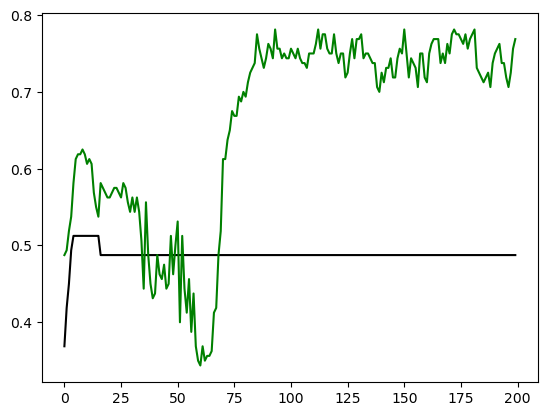

In [19]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')

As we can see that out batch normalisation model achieves the more than 60 percent accuracy only at 10epochs and at 170 epoch it performs best . Whereas second model poorly performs

The authors of the BN paper argued in favor of adding the BN layers before the acti
vation functions, rather than after (as we just did). There is some debate about this, as
it seems to depend on the task. So that’s one more thing you can experiment with to
see which option works best on your dataset. To add the BN layers before the activa
tion functions, we must remove the activation function from the hidden layers, and
add them as separate layers after the BN layers. Moreover, since a Batch Normaliza
tion layer includes one offset parameter per input, you can remove the bias term from
the previous layer (just pass use_bias=False when creating it):



model = keras.models.Sequential([

keras.layers.Flatten(input_shape=[28, 28]),

keras.layers.BatchNormalization(),

keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),

keras.layers.BatchNormalization(),

keras.layers.Activation("elu"),

keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),

keras.layers.Activation("elu"),

keras.layers.BatchNormalization(),

keras.layers.Dense(10, activation="softmax")
])